# CategoricalNB Model Training & Evaluation

Supports three dataset variants — set `VARIANT` in the config cell below:
- `"baseline"` → uses `x_train_categorized.csv` / `y_train.csv`
- `"undersampled"` → uses `x_train_undersampled.csv` / `y_train_undersampled.csv`
- `"oversampled"` → uses `x_train_oversampled.csv` / `y_train_oversampled.csv`

The **test set** (`x_test_categorized.csv` / `y_test.csv`) is shared across all variants.

**Pipeline:**
1. Set variant & load CSVs
2. Encode categories to integers
3. Train CategoricalNB model
4. Evaluate on test set (classification report, confusion matrix)

## 1. Setup & Imports

In [68]:
from IPython.display import display
import pandas as pd
import numpy as np
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

## 2. Dataset Variant Config

Change `VARIANT` to switch which training data is used.
Valid values: `"baseline"`, `"undersampled"`, `"oversampled"`

In [69]:
# ── Change this one line to switch datasets ──────────────────
VARIANT = "undersampled"   # "baseline" | "undersampled" | "oversampled"

TRAIN_X = {
    "baseline":     ".baseline/x_train.csv",
    "undersampled": ".undersampled/x_train_undersampled.csv",
    "oversampled":  ".oversampled/x_train_oversampled.csv",
}
TRAIN_Y = {
    "baseline":     ".baseline/y_train.csv",
    "undersampled": ".undersampled/y_train_undersampled.csv",
    "oversampled":  ".oversampled/y_train_oversampled.csv",
}

assert VARIANT in TRAIN_X, f"Unknown variant '{VARIANT}'. Choose: {list(TRAIN_X)}"
print(f"Running variant: {VARIANT}")
print(f"Train X : {TRAIN_X[VARIANT]}")
print(f"Train y : {TRAIN_Y[VARIANT]}")

Running variant: undersampled
Train X : .undersampled/x_train_undersampled.csv
Train y : .undersampled/y_train_undersampled.csv


## 3. Load Data

Loads training data for the selected variant and the shared test set.

In [70]:
X_train = pd.read_csv(TRAIN_X[VARIANT], dtype=str)
y_train = pd.read_csv(TRAIN_Y[VARIANT]).squeeze()
X_test  = pd.read_csv('.test_data/x_test.csv', dtype=str)
y_test  = pd.read_csv('.test_data/y_test.csv').squeeze()

print(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   |  y_test:  {y_test.shape}')
print(f'\nTrain class distribution:')
print(y_train.value_counts().sort_index())

X_train: (93690, 6)  |  y_train: (93690,)
X_test:  (100000, 6)   |  y_test:  (100000,)

Train class distribution:
sleep_stage
0    18738
1    18738
2    18738
3    18738
5    18738
Name: count, dtype: int64


## 4. Encode Categories → Integers

`CategoricalNB` requires non-negative integer inputs.
We use `OrdinalEncoder` fitted on training data and applied to both train and test.

In [71]:
FEATURES = ['hr_mean', 'hr_sdnn_5', 'hr_slope_3', 'rr_mean', 'rr_slope_3', 'minutes_since_start']
STAGE_NAMES = {0: 'Wake', 1: 'N1', 2: 'N2', 3: 'N3', 5: 'REM'}

encoder = OrdinalEncoder(dtype=int)
X_train_enc = encoder.fit_transform(X_train[FEATURES])
X_test_enc  = encoder.transform(X_test[FEATURES])

print('Encoding complete.')
print(f'X_train_enc shape: {X_train_enc.shape}')
print(f'X_test_enc  shape: {X_test_enc.shape}')

print('\nCategory → Integer mapping:')
for feat, cats in zip(FEATURES, encoder.categories_):
    mapping = {cat: i for i, cat in enumerate(cats)}
    print(f'  {feat}: {mapping}')

Encoding complete.
X_train_enc shape: (93690, 6)
X_test_enc  shape: (100000, 6)

Category → Integer mapping:
  hr_mean: {'Bradycardia': 0, 'Normal': 1, 'Tachycardia': 2}
  hr_sdnn_5: {'High': 0, 'Low': 1, 'Moderate': 2}
  hr_slope_3: {'Decreasing': 0, 'Increasing': 1, 'Stable': 2}
  rr_mean: {'High': 0, 'Low': 1, 'Normal': 2}
  rr_slope_3: {'Decreasing': 0, 'Increasing': 1, 'Stable': 2}
  minutes_since_start: {'Early': 0, 'Late': 1, 'Mid': 2}


## 5. Train CategoricalNB

`alpha=1.0` (Laplace smoothing) — adds 1 to every count before computing probabilities.

In [72]:
model = CategoricalNB(alpha=1.0)
model.fit(X_train_enc, y_train)

print('Model trained successfully.')
print(f'Classes:  {model.classes_}')
print(f'Features: {model.n_features_in_}')

Model trained successfully.
Classes:  [0 1 2 3 5]
Features: 6


## 6. Evaluate on Test Set

In [73]:
y_pred = model.predict(X_test_enc)
target_names = [STAGE_NAMES[c] for c in model.classes_]

# --- Classification Report ---
print('=' * 60)
print(f'  CLASSIFICATION REPORT — {VARIANT.upper()}')
print('=' * 60)
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

# --- Summary Metrics ---
metrics_data = {
    'Metric': ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1 Score (weighted)'],
    'Score': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_pred, average='weighted', zero_division=0),
    ]
}
metrics_df = pd.DataFrame(metrics_data)
metrics_df['Score'] = metrics_df['Score'].map(lambda x: f'{x:.4f}')
print('=' * 60)
print(f'  SUMMARY TABLE — {VARIANT.upper()}')
print('=' * 60)
display(metrics_df)

  CLASSIFICATION REPORT — UNDERSAMPLED
              precision    recall  f1-score   support

        Wake       0.63      0.55      0.58     30883
          N1       0.10      0.25      0.14      4685
          N2       0.59      0.20      0.30     39987
          N3       0.24      0.62      0.34     11037
         REM       0.25      0.35      0.29     13408

    accuracy                           0.38    100000
   macro avg       0.36      0.39      0.33    100000
weighted avg       0.49      0.38      0.38    100000

  SUMMARY TABLE — UNDERSAMPLED


,Metric,Score
0,Accuracy,0.3765
1,Precision (weighted),0.4930
2,Recall (weighted),0.3765
3,F1 Score (weighted),0.3837


## 7. Confusion Matrix

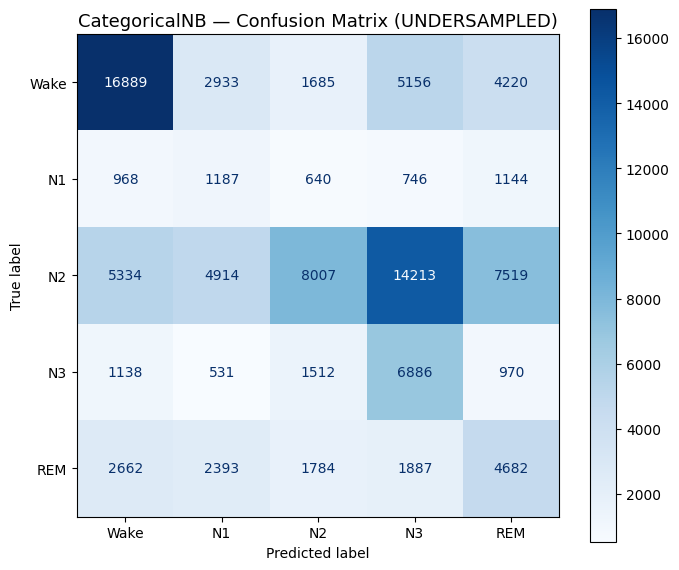

In [74]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=target_names,
    cmap='Blues',
    ax=ax
)
ax.set_title(f'CategoricalNB — Confusion Matrix ({VARIANT.upper()})', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Confusion Matrix Breakdown

Per-class True Positives, False Positives, False Negatives, and True Negatives.

In [75]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

print(f'Confusion Matrix Breakdown — {VARIANT.upper()}')
print('=' * 65)

breakdown_rows = []
for i, class_label in enumerate(model.classes_):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = cm.sum() - tp - fp - fn

    name = STAGE_NAMES[class_label]
    print(f'\n  {name} (class {class_label}):')
    print(f'    True Positives  (correctly predicted {name}):     {tp:,}')
    print(f'    False Positives (incorrectly predicted {name}):   {fp:,}')
    print(f'    False Negatives (missed actual {name} cases):     {fn:,}')
    print(f'    True Negatives  (correctly predicted not {name}): {tn:,}')
    breakdown_rows.append({'Col1': f'{name} (class {class_label})', 'Col2': f'True Positives (correctly predicted {name})', 'Col3': tp})
    breakdown_rows.append({'Col1': '', 'Col2': f'False Positives (incorrectly predicted {name})', 'Col3': fp})
    breakdown_rows.append({'Col1': '', 'Col2': f'False Negatives (missed actual {name} cases)', 'Col3': fn})
    breakdown_rows.append({'Col1': '', 'Col2': f'True Negatives (correctly predicted not {name})', 'Col3': tn})

# --- Combine and Export ---
metrics_df_export = metrics_df.copy()
metrics_df_export['Col3'] = ''
metrics_df_export.columns = ['Col1', 'Col2', 'Col3']
breakdown_df = pd.DataFrame(breakdown_rows)
spacer = pd.DataFrame([{'Col1': '', 'Col2': '', 'Col3': ''}])
final_df = pd.concat([metrics_df_export, spacer, breakdown_df], ignore_index=True)
final_df.columns = ['Metric', 'Score', '']
final_path = f'evaluation_results_{VARIANT}.csv'
final_df.to_csv(final_path, index=False)
print(f'\nSaved combined evaluation results to {final_path}')


Confusion Matrix Breakdown — UNDERSAMPLED

  Wake (class 0):
    True Positives  (correctly predicted Wake):     16,889
    False Positives (incorrectly predicted Wake):   10,102
    False Negatives (missed actual Wake cases):     13,994
    True Negatives  (correctly predicted not Wake): 59,015

  N1 (class 1):
    True Positives  (correctly predicted N1):     1,187
    False Positives (incorrectly predicted N1):   10,771
    False Negatives (missed actual N1 cases):     3,498
    True Negatives  (correctly predicted not N1): 84,544

  N2 (class 2):
    True Positives  (correctly predicted N2):     8,007
    False Positives (incorrectly predicted N2):   5,621
    False Negatives (missed actual N2 cases):     31,980
    True Negatives  (correctly predicted not N2): 54,392

  N3 (class 3):
    True Positives  (correctly predicted N3):     6,886
    False Positives (incorrectly predicted N3):   22,002
    False Negatives (missed actual N3 cases):     4,151
    True Negatives  (correctly 